# 02 - Convolutional VAE + k-means

Learns a 16-dimensional summary of each daily scalogram (128 scales x 24 hours). K-means on those summaries plus the daily price level assigns each day to a market regime.

Pipeline: scalogram -> ConvVAE encoder -> latent mean (mu) + daily price level -> k-means -> regime

Methodology notes:
1. Days are split chronologically (60% train, 20% validation, 20% test). The 2023-2024 El Nino falls in the test period.
2. The k-means is fitted on training days only and then applied to all days.
3. Scalograms come from the real price with each day's mean removed, so they show only the intraday shape. `real_price_log` uses the log real price and `real_price` the real price in COP/kWh. The daily level (mean and standard deviation of the same series) is added to the latent vector before clustering.
4. Each run creates a folder in `experiments/conv_vae/<clustering>/` with config, history, metrics, tables and figures, and adds one row to `experiments/registry.csv`.

<d.benavidess@uniandes.edu.co>

In [1]:
import sys
sys.path.append("..")

from pathlib import Path

import torch

import numpy as np
import pandas as pd
import altair as alt
import matplotlib.pyplot as plt
from prettytable import PrettyTable
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader

plt.rcParams['font.family'] = 'Arial'
alt.data_transformers.enable('vegafusion')

from src.data import load_scalograms, load_context, chronological_split, ScalogramDataset
from src.models.conv_vae import ConvVAE
from src.training import set_seed, train
from src.clustering import with_level, level_columns, assign_regimes, fit_clusters, order_regimes, summary_metrics, regime_profile, save_regimes
from src.plots import loss_curves, selection_chart, tsne_chart, regime_timeline, plot_reconstructions
from src import experiments as exp

In [2]:
import warnings
warnings.filterwarnings("ignore")

## 0. Experiment configuration

In [3]:
SCALOGRAM_SET = "real_price_log"
CLUSTERING = "kmeans"
N_REGIMES = 2

CONFIG = {
    "model": "conv_vae",
    "scalogram_set": SCALOGRAM_SET,
    "clustering": CLUSTERING,
    "n_regimes": N_REGIMES,
    "k_range": [2, 3, 4, 5, 6, 7, 8],
    "z_dim": 16,
    "filters": [128, 64, 32],
    "beta": 1.0,
    "kl_warmup_epochs": 0,
    "optimizer": "Adam",
    "lr": 1e-3,
    "batch_size": 64,
    "epochs": 30,
    "train_ratio": 0.6,
    "val_ratio": 0.2,
    "seed": 42,
}

## 1. Run folder

In [4]:
SCALOGRAM_DIR = Path("../data/processed/scalograms") / SCALOGRAM_SET
DATA_DIR = Path("../data/processed")

RUN_DIR = exp.create_run(CLUSTERING, SCALOGRAM_SET, CLUSTERING, N_REGIMES, root=exp.EXPERIMENTS_DIR / CONFIG["model"])
exp.save_config(RUN_DIR, CONFIG)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(CONFIG["seed"])
print(f"Run: {exp.run_id(RUN_DIR)}")
print(f"Device: {DEVICE}")

Run: conv_vae/003_real_price_log_kmeans_k2
Device: cpu


## 2. Data

In [5]:
images, metadata = load_scalograms(SCALOGRAM_DIR)
context = load_context(DATA_DIR, metadata)
train_idx, val_idx, test_idx = chronological_split(len(images), CONFIG["train_ratio"], CONFIG["val_ratio"])
split_dates = [context["date"].iloc[val_idx[0]], context["date"].iloc[test_idx[0]]]

IMG_C, IMG_H, IMG_W = images.shape[1:]
print(f"Scalograms ({SCALOGRAM_SET}): {images.shape}, range [{images.min():.3f}, {images.max():.3f}]")
print(f"Daily level columns: {level_columns(metadata)}")
exp.save_table(RUN_DIR, "splits", exp.split_table(context, {"train": train_idx, "val": val_idx, "test": test_idx}))

Scalograms (real_price_log): (9709, 1, 128, 24), range [0.000, 1.000]
Daily level columns: ('log_price_mean', 'log_price_std')
+-------+------+------------+------------+
| Split | Days |    From    |     To     |
+-------+------+------------+------------+
| train | 5825 | 2000-01-01 | 2015-12-12 |
|  val  | 1942 | 2015-12-13 | 2021-04-06 |
|  test | 1942 | 2021-04-07 | 2026-07-31 |
+-------+------+------------+------------+


In [6]:
train_loader = DataLoader(ScalogramDataset(images, train_idx), batch_size=CONFIG["batch_size"], shuffle=True)
val_loader = DataLoader(ScalogramDataset(images, val_idx), batch_size=CONFIG["batch_size"], shuffle=False)

In [7]:
def bce_floor(x):
    x = np.clip(x.reshape(len(x), -1).astype(np.float64), 1e-7, 1 - 1e-7)
    return -(x * np.log(x) + (1 - x) * np.log(1 - x)).sum(axis=1)

for name, idx in (("train", train_idx), ("val", val_idx), ("test", test_idx)):
    f = bce_floor(images[idx])
    print(f"{name}: floor {f.mean():.0f}, mean pixel {images[idx].mean():.3f}")

train: floor 952, mean pixel 0.136
val: floor 983, mean pixel 0.141
test: floor 954, mean pixel 0.167


## 3. Model

In [8]:
model = ConvVAE(CONFIG["z_dim"], IMG_C, IMG_H, IMG_W, CONFIG["filters"]).to(DEVICE)

with torch.no_grad():
    out_shape = tuple(model(torch.from_numpy(images[:2]).to(DEVICE))[0].shape[1:])
assert out_shape == (IMG_C, IMG_H, IMG_W), f"decoder output {out_shape} does not match input"

N_PARAMS = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Encoder feature map: {model.encoder.feat_shape}")
print(f"Decoder output: {out_shape}")
exp.save_table(RUN_DIR, "hyperparameters", exp.hyperparameter_table(CONFIG, N_PARAMS))

Encoder feature map: (32, 16, 3)
Decoder output: (1, 128, 24)
+----------------------------+-----------------+
| Hyperparameter             |      Value      |
+----------------------------+-----------------+
| Latent dimension           |        16       |
| Encoder filters            | 128 -> 64 -> 32 |
| Decoder filters            | 32 -> 64 -> 128 |
| Beta (KL weight)           |       1.0       |
| Smoothness weight (lambda) |        -        |
| KL warm-up epochs          |        0        |
| Optimizer, learning rate   |   Adam, 0.001   |
| Batch size                 |        64       |
| Epochs                     |        30       |
| Trainable parameters       |     263,169     |
+----------------------------+-----------------+


## 4. Training

In [9]:
history = train(model, train_loader, val_loader, DEVICE, epochs=CONFIG["epochs"], lr=CONFIG["lr"],
                beta=CONFIG["beta"], kl_warmup_epochs=CONFIG["kl_warmup_epochs"])
exp.save_history(RUN_DIR, history)
exp.save_model(RUN_DIR, model)

Epoch   1/30  train: total=1141.80  recon=1120.19  kl=21.60  val total=1042.59
Epoch   5/30  train: total=990.45  recon=978.31  kl=12.14  val total=1029.24
Epoch  10/30  train: total=980.03  recon=970.58  kl=9.45  val total=1006.15
Epoch  15/30  train: total=978.58  recon=971.94  kl=6.64  val total=999.46
Epoch  20/30  train: total=989.15  recon=983.26  kl=5.89  val total=1003.16
Epoch  25/30  train: total=976.90  recon=970.98  kl=5.92  val total=995.92
Epoch  30/30  train: total=967.22  recon=961.56  kl=5.66  val total=995.46


## 5. Loss curves

In [10]:
loss_plot = loss_curves(history, components=("total", "recon", "kl"))
loss_plot

alt.HConcatChart(...)

In [11]:
loss_plot.save(exp.figure_path(RUN_DIR, "loss_curves"), scale_factor=2.0)

## 6. Reconstructions

Test-period days.

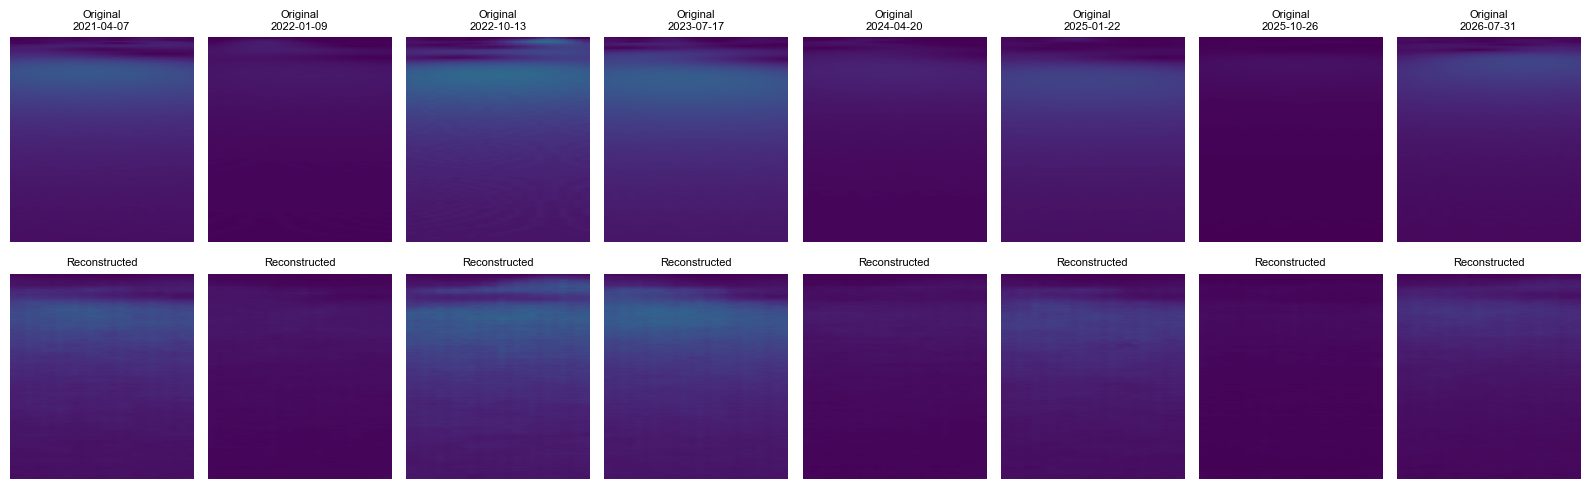

In [12]:
model.eval()
show_idx = test_idx[np.linspace(0, len(test_idx) - 1, 8).astype(int)]
with torch.no_grad():
    recon = model(torch.from_numpy(images[show_idx]).to(DEVICE))[0].cpu().numpy()

fig = plot_reconstructions(images[show_idx], recon, [str(d.date()) for d in context["date"].iloc[show_idx]])
fig.savefig(exp.figure_path(RUN_DIR, "reconstructions"), dpi=150, bbox_inches="tight")
plt.show()

## 7. Latent vectors

In [13]:
latents = model.extract_latents(images, DEVICE)
exp.save_latents(RUN_DIR, latents)
features = with_level(latents, metadata, train_idx)

active = int((latents.var(axis=0) > 0.01).sum())
print(f"Latent vectors: {latents.shape}")
print(f"Final train KL: {history[-1]['train_kl']:.2f}")
print(f"Active dimensions: {active} of {CONFIG['z_dim']}")
print(f"Clustering features (latents + daily level): {features.shape}")

Latent vectors: (9709, 16)
Final train KL: 5.66
Active dimensions: 15 of 16
Clustering features (latents + daily level): (9709, 18)


## 8. Regimes with k-means

K-means uses the latent vector plus the daily price level (mean and standard deviation, z-scored on training days), the same input as the GMM notebooks, because the scalograms only carry the intraday shape. It is fitted on the training days only and then assigns every day. k comes from `N_REGIMES`. The table shows, for each k on the training days, the inertia (look for the elbow, the role the BIC plays for the GMM), silhouette (higher is better), Davies-Bouldin (lower is better) and Calinski-Harabasz (higher is better). Regimes are numbered by ascending mean real price, so regime 0 is always the cheapest and labels are comparable across models.

In [14]:
selection, K, labels, probs = assign_regimes(
    features, train_idx, context["precio_real_cop_kwh"].to_numpy(),
    k=N_REGIMES, k_range=CONFIG["k_range"], seed=CONFIG["seed"], method=CLUSTERING,
)
context["regime"] = labels

exp.save_table(RUN_DIR, "k_selection", exp.selection_table(selection))
print(f"Selected k = {K}")

  File "c:\Users\Daniel Benavides\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Daniel Benavides\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Daniel Benavides\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Daniel Benavides\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


+---+---------+------------+----------------+-------------------+
| k | Inertia | Silhouette | Davies-Bouldin | Calinski-Harabasz |
+---+---------+------------+----------------+-------------------+
| 2 |  26,473 |   0.342    |     1.407      |       2,455       |
| 3 |  22,488 |   0.239    |     1.503      |       1,961       |
| 4 |  19,709 |   0.224    |     1.415      |       1,765       |
| 5 |  17,910 |   0.243    |     1.333      |       1,602       |
| 6 |  16,145 |   0.232    |     1.339      |       1,549       |
| 7 |  15,082 |   0.211    |     1.374      |       1,450       |
| 8 |  14,067 |   0.222    |     1.335      |       1,392       |
+---+---------+------------+----------------+-------------------+
Selected k = 2


In [15]:
selection_plot = selection_chart(selection, K)
selection_plot

alt.HConcatChart(...)

In [16]:
selection_plot.save(exp.figure_path(RUN_DIR, "k_selection"), scale_factor=2.0)

## 9. Latent space

In [17]:
rng = np.random.default_rng(CONFIG["seed"])
plot_idx = np.sort(rng.choice(len(features), size=min(5000, len(features)), replace=False))
coords = TSNE(n_components=2, perplexity=30, random_state=CONFIG["seed"]).fit_transform(features[plot_idx])

tsne_plot = tsne_chart(coords, labels[plot_idx], f"t-SNE of the latent space (k={K})")
tsne_plot

alt.Chart(...)

In [18]:
tsne_plot.save(exp.figure_path(RUN_DIR, "tsne_regimes"), scale_factor=2.0)

## 10. Regime timeline

Shaded bands are El Nino months (ONI >= 0.5). Dashed lines mark the start of the validation and test periods.

In [19]:
timeline_plot = regime_timeline(context, split_dates, title=f"Detected regimes over time (k={K})")
timeline_plot

alt.VConcatChart(...)

In [20]:
timeline_plot.save(exp.figure_path(RUN_DIR, "regime_timeline"), scale_factor=2.0)

## 11. Regime profile and clustering metrics

In [21]:
exp.save_table(RUN_DIR, "regime_profile", exp.regime_profile_table(regime_profile(context)))

+--------+------+---------+------------+-----------+----------+-----------+
| Regime | Days | Share % | Real price | Reservoir | Mean ONI | El Nino % |
+--------+------+---------+------------+-----------+----------+-----------+
|   0    | 3081 |   31.7  |   281.6    |   0.703   |  -0.15   |    17.3   |
|   1    | 6628 |   68.3  |   332.1    |   0.667   |   0.07   |    28.2   |
+--------+------+---------+------------+-----------+----------+-----------+


In [22]:
metrics = {"run_id": exp.run_id(RUN_DIR), "model": CONFIG["model"], "scalogram_set": SCALOGRAM_SET,
           "clustering": CLUSTERING, "k": K, **summary_metrics(features, labels, seed=CONFIG["seed"])}
save_regimes(RUN_DIR, context, labels, probs, metrics)
exp.save_table(RUN_DIR, "clustering_metrics", exp.metrics_table(metrics))
exp.log_run(RUN_DIR, CONFIG, metrics, registry=exp.EXPERIMENTS_DIR / "registry.csv")

+-------------------+---------------------------------------+
| Metric            |                 Value                 |
+-------------------+---------------------------------------+
| run_id            | conv_vae/003_real_price_log_kmeans_k2 |
| model             |                conv_vae               |
| scalogram_set     |             real_price_log            |
| clustering        |                 kmeans                |
| k                 |                   2                   |
| regimes           |                   2                   |
| silhouette        |                 0.319                 |
| davies_bouldin    |                 1.468                 |
| calinski_harabasz |                3774.730               |
| mean_run_days     |                 4.795                 |
| median_run_days   |                 2.000                 |
| switches_per_year |                 76.142                |
+-------------------+---------------------------------------+


{'run_id': 'conv_vae/003_real_price_log_kmeans_k2',
 'date': '2026-10-07T14:54:22',
 'model': 'conv_vae',
 'scalogram_set': 'real_price_log',
 'clustering': 'kmeans',
 'k': 2,
 'filters': '128-64-32',
 'z_dim': 16,
 'beta': 1.0,
 'lam': '',
 'kl_warmup_epochs': 0,
 'epochs': 30,
 'silhouette': 0.3186,
 'davies_bouldin': 1.4682,
 'calinski_harabasz': 3774.7298,
 'mean_run_days': 4.7946,
 'switches_per_year': 76.1423,
 'git_commit': 'cfc7138'}

In [23]:
spread = context.groupby("regime")["precio_real_cop_kwh"].describe(percentiles=[0.1, 0.5, 0.9])
spread[["count", "10%", "50%", "90%", "min", "max"]].round(1)

,count,10%,50%,90%,min,max
regime,,,,,,
0,3081.0,139.2,214.8,485.3,85.1,3410.9
1,6628.0,134.3,238.9,631.1,76.1,3582.7


## 12. Exploratory checks

In [24]:
price = context["precio_real_cop_kwh"].to_numpy()
level = with_level(np.zeros((len(latents), 0)), metadata, train_idx)
smooth = pd.DataFrame(latents).rolling(7, min_periods=1).mean().to_numpy()

rows = (
    ("level only", level),
    ("latents only", latents),
    ("latents + level", features),
    ("7d-mean latents + level", with_level(smooth, metadata, train_idx)),
)
t = PrettyTable(["Features", "Silhouette", "Davies-Bouldin", "Mean run", "Switches / yr", "Median price by regime"])
for name, f in rows:
    lab = order_regimes(fit_clusters(f, train_idx, K, CLUSTERING, CONFIG["seed"])[0], price)
    m = summary_metrics(f, lab, seed=CONFIG["seed"])
    med = context.assign(r=lab).groupby("r")["precio_real_cop_kwh"].median().round(0).tolist()
    t.add_row([name, f"{m['silhouette']:.3f}", f"{m['davies_bouldin']:.3f}", f"{m['mean_run_days']:.1f}",
               f"{m['switches_per_year']:.0f}", med])
print(t)
print(pd.crosstab(labels, context["date"].dt.dayofweek, normalize="columns").mul(100).round(0))

+-------------------------+------------+----------------+----------+---------------+------------------------+
|         Features        | Silhouette | Davies-Bouldin | Mean run | Switches / yr | Median price by regime |
+-------------------------+------------+----------------+----------+---------------+------------------------+
|        level only       |   0.364    |     1.084      |   6.2    |       59      |     [184.0, 263.0]     |
|       latents only      |   0.323    |     1.447      |   4.0    |       91      |     [226.0, 244.0]     |
|     latents + level     |   0.319    |     1.468      |   4.8    |       76      |     [215.0, 239.0]     |
| 7d-mean latents + level |   0.303    |     1.428      |   8.7    |       42      |     [197.0, 252.0]     |
+-------------------------+------------+----------------+----------+---------------+------------------------+
date      0     1     2     3     4     5     6
row_0                                          
0      36.0  38.0  37.0 

In [25]:
print("Latent variance per dim:", np.round(latents.var(axis=0), 5))
print("Latent std range:", latents.std(axis=0).min().round(4), "to", latents.std(axis=0).max().round(4))

Latent variance per dim: [0.02959 0.81694 0.01662 0.02896 0.07146 0.05472 0.0205  0.02493 0.0118
 0.00623 0.72474 2.17486 0.09947 0.90515 0.04128 0.03005]
Latent std range: 0.0789 to 1.4747
